<a href="https://colab.research.google.com/github/isabela2206/lia1_2026_2/blob/main/Exerc%C3%ADciosPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios práticos (1.1 Numpy e Pandas)

### Desafio 1

In [21]:
import pandas as pd
import numpy as np

dados_vendas = {
    'Vendedor': ['Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana'] * 3,
    'Produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'] * 6,
    'Regiao': ['Norte', 'Sul', 'Nordeste', 'Centro-Oeste', 'Sudeste'] * 6,
    'Vendas': np.random.randint(1000, 10000, 30),
    'Quantidade': np.random.randint(1, 20, 30)
}

df_vendas_completo = pd.DataFrame(dados_vendas)
print("DataFrame de vendas:")
df_vendas_completo.head(10)

DataFrame de vendas:


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,4347,17
1,João,Mouse,Sul,8919,6
2,Pedro,Teclado,Nordeste,2857,9
3,Ana,Monitor,Centro-Oeste,1027,2
4,João,Headset,Sudeste,2183,6
5,Pedro,Notebook,Norte,2306,15
6,Ana,Mouse,Sul,7054,11
7,João,Teclado,Nordeste,1420,18
8,Pedro,Monitor,Centro-Oeste,4367,11
9,Ana,Headset,Sudeste,8726,15


In [22]:
# Vendedor com maior número de vendas
vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()
maior_vendedor = vendas_por_vendedor.idxmax()

In [23]:
# Região com maior faturamento total
faturamento_por_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()
maior_regiao = faturamento_por_regiao.idxmax()

In [24]:
# Produto mais vendido em quantidade
quantidade_de_produto = df_vendas_completo.groupby('Produto')['Quantidade'].sum()
maior_produto = quantidade_de_produto.idxmax()

In [25]:
# Cálculos
vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()
faturamento_por_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()
quantidade_por_produto = df_vendas_completo.groupby('Produto')['Quantidade'].sum()

# Tabela-resumo
df_resumo_top3 = pd.DataFrame({
    'Pergunta': [
        'Vendedor com maior faturamento',
        'Região com maior faturamento',
        'Produto mais vendido (quantidade)'
    ],
    'Resposta': [
        vendas_por_vendedor.idxmax(),
        faturamento_por_regiao.idxmax(),
        quantidade_por_produto.idxmax()
    ],
    'Valor': [
        vendas_por_vendedor.max(),
        faturamento_por_regiao.max(),
        quantidade_por_produto.max()
    ]
})

print("Tabela-resumo:")
df_resumo_top3

Tabela-resumo:


,Pergunta,Resposta,Valor
0,Vendedor com maior faturamento,Ana,73833
1,Região com maior faturamento,Sul,50714
2,Produto mais vendido (quantidade),Teclado,72


In [26]:
media_vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].mean()
print(media_vendas_por_vendedor.round(2))

Vendedor
Ana      6152.75
João     5025.11
Pedro    5123.56
Name: Vendas, dtype: float64


### Desafio 2

In [27]:
import pandas as pd
import numpy as np

# Criando um DataFrame com dados "problemáticos"
dados_problematicos = {
    'Nome': ['ana silva', 'João Souza', 'PEDRO costa', 'Ana Silva', 'maria oliveira',
              'joão souza', 'Pedro Costa', 'Maria Oliveira', 'ana silva', np.nan],
    'Cidade': [' São Paulo', 'rio de janeiro', 'Belo Horizonte ', 'São Paulo', 'CURITIBA',
               'Rio de Janeiro', 'belo horizonte', np.nan, ' São Paulo', 'Curitiba'],
    'Idade': [28, 34, np.nan, 28, 41, 34, 45, 29, 28, 30],
    'Vendas': [1500.50, 2300.00, 1800.75, 1500.50, np.nan,
               2300.00, 1800.75, 2100.00, 1500.50, 1950.00]
}

df_problematico = pd.DataFrame(dados_problematicos)
print("DataFrame original (problemático):")
df_problematico

DataFrame original (problemático):


,Nome,Cidade,Idade,Vendas
0,ana silva,São Paulo,28.0,1500.50
1,João Souza,rio de janeiro,34.0,2300.00
2,PEDRO costa,Belo Horizonte,NaN,1800.75
3,Ana Silva,São Paulo,28.0,1500.50
4,maria oliveira,CURITIBA,41.0,NaN
5,joão souza,Rio de Janeiro,34.0,2300.00
6,Pedro Costa,belo horizonte,45.0,1800.75
7,Maria Oliveira,NaN,29.0,2100.00
8,ana silva,São Paulo,28.0,1500.50
9,NaN,Curitiba,30.0,1950.00


In [28]:
# Remoção de duplicata
print(f"Duplicatas encontradas: {df_problematico.duplicated().sum()}")
df_limpo = df_problematico.drop_duplicates()
print(f"Linhas antes: {len(df_problematico)} | Linhas depois: {len(df_limpo)}")

Duplicatas encontradas: 1
Linhas antes: 10 | Linhas depois: 9


In [29]:
# Tratamento de valores ausentes
print("Valores ausentes por coluna:")
print(df_limpo.isna().sum())

# Nome
df_limpo = df_limpo.dropna(subset=['Nome'])

# Cidade
df_limpo['Cidade'] = df_limpo['Cidade'].fillna('Não informado')

# Idade
df_limpo['Idade'] = df_limpo['Idade'].fillna(df_limpo['Idade'].mean())

# Vendas
df_limpo['Vendas'] = df_limpo['Vendas'].fillna(df_limpo['Vendas'].median())

print("Após tratar valores ausentes:")
df_limpo

Valores ausentes por coluna:
Nome      1
Cidade    1
Idade     1
Vendas    1
dtype: int64
Após tratar valores ausentes:


,Nome,Cidade,Idade,Vendas
0,ana silva,São Paulo,28.000000,1500.50
1,João Souza,rio de janeiro,34.000000,2300.00
2,PEDRO costa,Belo Horizonte,34.142857,1800.75
3,Ana Silva,São Paulo,28.000000,1500.50
4,maria oliveira,CURITIBA,41.000000,1800.75
5,joão souza,Rio de Janeiro,34.000000,2300.00
6,Pedro Costa,belo horizonte,45.000000,1800.75
7,Maria Oliveira,Não informado,29.000000,2100.00


In [30]:
# Padronização de strings
df_limpo['Nome'] = df_limpo['Nome'].str.strip().str.title()
df_limpo['Cidade'] = df_limpo['Cidade'].str.strip().str.title()
df_limpo = df_limpo.drop_duplicates()
print(f"Linhas após remover duplicatas 'escondidas' pela formatação: {len(df_limpo)}")
df_limpo

Linhas após remover duplicatas 'escondidas' pela formatação: 6


,Nome,Cidade,Idade,Vendas
0,Ana Silva,São Paulo,28.000000,1500.50
1,João Souza,Rio De Janeiro,34.000000,2300.00
2,Pedro Costa,Belo Horizonte,34.142857,1800.75
4,Maria Oliveira,Curitiba,41.000000,1800.75
6,Pedro Costa,Belo Horizonte,45.000000,1800.75
7,Maria Oliveira,Não Informado,29.000000,2100.00


In [31]:
# Criação de novas colunas derivadas
df_limpo['Categoria_Venda'] = np.where(df_limpo['Vendas'] >= 2000, 'Alta', 'Baixa')
df_limpo

/tmp/ipykernel_1709/195669766.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpo['Categoria_Venda'] = np.where(df_limpo['Vendas'] >= 2000, 'Alta', 'Baixa')


,Nome,Cidade,Idade,Vendas,Categoria_Venda
0,Ana Silva,São Paulo,28.000000,1500.50,Baixa
1,João Souza,Rio De Janeiro,34.000000,2300.00,Alta
2,Pedro Costa,Belo Horizonte,34.142857,1800.75,Baixa
4,Maria Oliveira,Curitiba,41.000000,1800.75,Baixa
6,Pedro Costa,Belo Horizonte,45.000000,1800.75,Baixa
7,Maria Oliveira,Não Informado,29.000000,2100.00,Alta


### Desafio 3

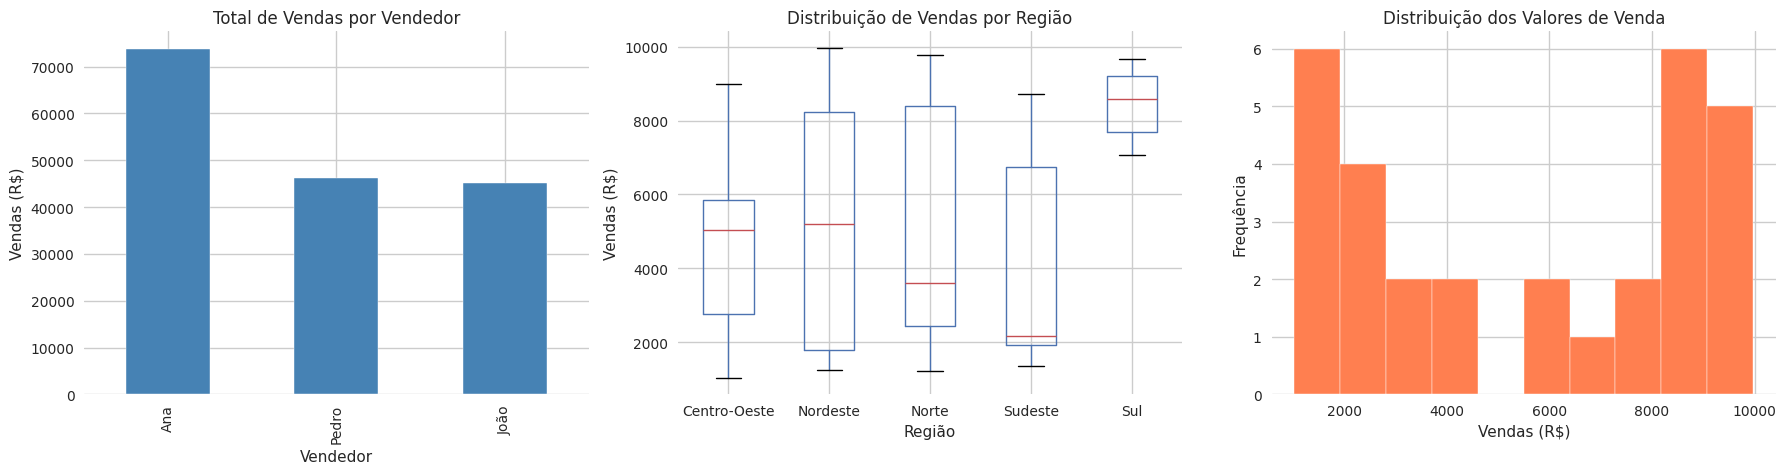

In [32]:
# Comparação entre vendedores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum().sort_values(ascending=False)

vendas_por_vendedor.plot(
    kind='bar',
    ax=axes[0],
    color='steelblue',
    title='Total de Vendas por Vendedor',
    xlabel='Vendedor',
    ylabel='Vendas (R$)'
)
# Tendências por região
df_vendas_completo.boxplot(
    column='Vendas',
    by='Regiao',
    ax=axes[1]
)
axes[1].set_title('Distribuição de Vendas por Região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Vendas (R$)')
# Distribuição de valores
df_vendas_completo['Vendas'].plot(
    kind='hist',
    bins=10,
    ax=axes[2],
    color='coral',
    title='Distribuição dos Valores de Venda',
    xlabel='Vendas (R$)',
    ylabel='Frequência'
)

plt.suptitle('')  # remove o título automático "Boxplot grouped by..." que o pandas adiciona
plt.tight_layout()
plt.show()

# Desafio final (1.2 Matplotlib e Seaborn)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [34]:
pd.read_csv('/train.csv')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [35]:
df = pd.read_csv('/train.csv')
print(f"Dimensões: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Dimensões: (8693, 14)
Colunas: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [36]:
print("ℹ Tipos de dados:")
print(df.dtypes)
print("\n Estatísticas descritivas:")
df.describe()

ℹ Tipos de dados:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

 Estatísticas descritivas:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [37]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183


In [38]:
colunas_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

colunas_categoricas = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']
for col in colunas_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

df['CryoSleep'] = df['CryoSleep'].astype(bool)
df['VIP'] = df['VIP'].astype(bool)

df = df.dropna(subset=['Cabin'])

df['Deck'] = df['Cabin'].str.split('/').str[0]
df['Side'] = df['Cabin'].str.split('/').str[2]

print(f" Dimensões finais: {df.shape}")
print(f" Valores ausentes restantes: {df.isnull().sum().sum()}")

 Dimensões finais: (8494, 16)
 Valores ausentes restantes: 198


/tmp/ipykernel_1709/2599601303.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [39]:
colunas_gastos = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['Gasto_Total'] = df[colunas_gastos].sum(axis=1)

df['Faixa_Etaria'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 100],
                             labels=['Criança', 'Adolescente', 'Adulto', 'Idoso'])

taxa_transportado = df['Transported'].mean()
print(f"📊 Taxa geral de passageiros transportados: {taxa_transportado:.1%}")
df[['Gasto_Total', 'Faixa_Etaria']].head()

📊 Taxa geral de passageiros transportados: 50.4%


,Gasto_Total,Faixa_Etaria
0,0.0,Adulto
1,736.0,Adulto
2,10383.0,Idoso
3,5176.0,Adulto
4,1091.0,Adolescente


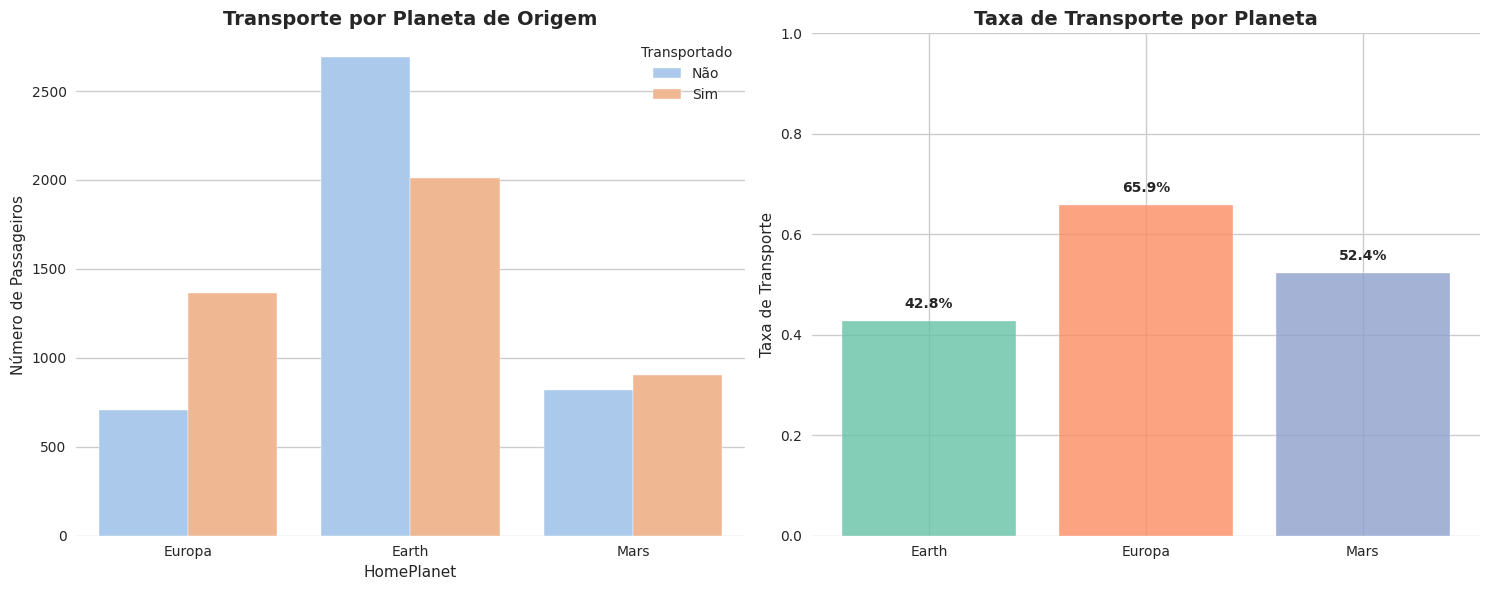

Transported  False  True   All
HomePlanet                    
Earth         2690  2012  4702
Europa         706  1364  2070
Mars           820   902  1722
All           4216  4278  8494


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='HomePlanet', hue='Transported', data=df, palette='pastel', ax=ax1)
ax1.set_title('Transporte por Planeta de Origem', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Passageiros')
ax1.legend(title='Transportado', labels=['Não', 'Sim'])

transporte_planeta = df.groupby('HomePlanet')['Transported'].mean()
ax2.bar(transporte_planeta.index, transporte_planeta.values, color=['#66c2a5', '#fc8d62', '#8da0cb'], alpha=0.8)
ax2.set_title('Taxa de Transporte por Planeta', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Transporte')
ax2.set_ylim(0, 1)
for i, v in enumerate(transporte_planeta.values):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(pd.crosstab(df['HomePlanet'], df['Transported'], margins=True))

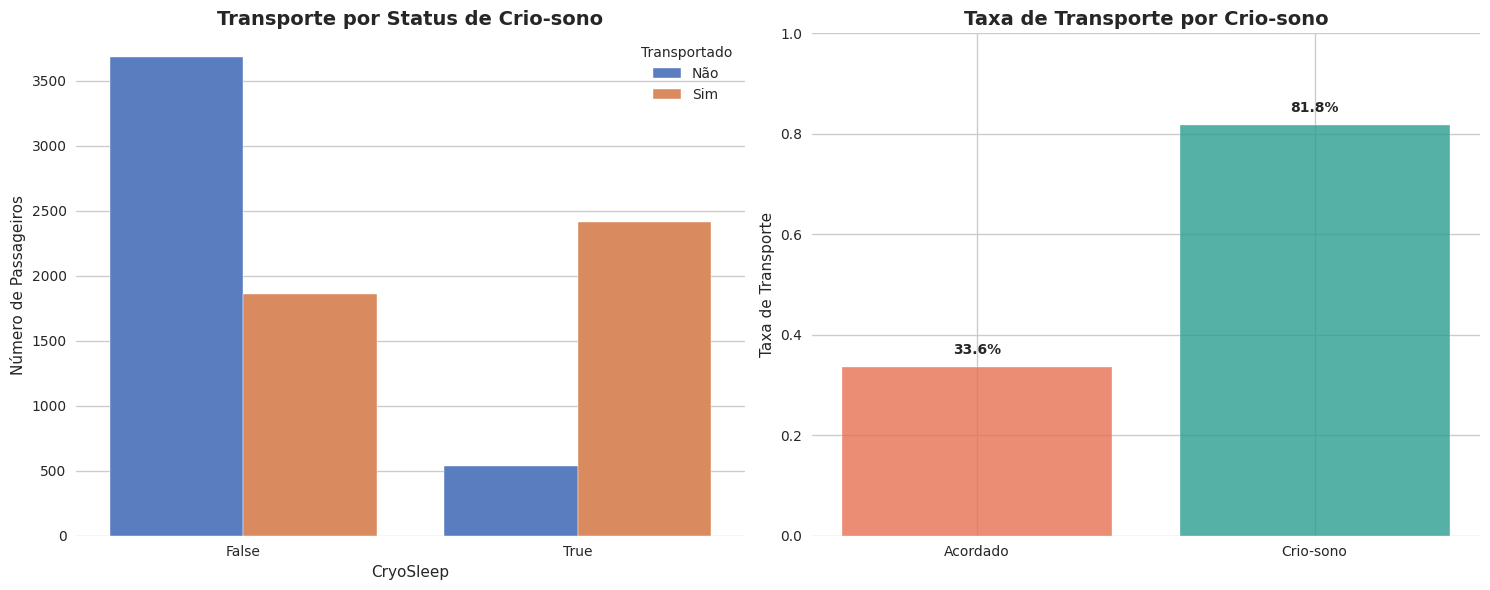

Transported  False  True   All
CryoSleep                     
False         3679  1862  5541
True           537  2416  2953
All           4216  4278  8494


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='CryoSleep', hue='Transported', data=df, palette='muted', ax=ax1)
ax1.set_title('Transporte por Status de Crio-sono', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Passageiros')
ax1.legend(title='Transportado', labels=['Não', 'Sim'])

transporte_cryo = df.groupby('CryoSleep')['Transported'].mean()
ax2.bar(['Acordado', 'Crio-sono'], transporte_cryo.values, color=['#e76f51', '#2a9d8f'], alpha=0.8)
ax2.set_title('Taxa de Transporte por Crio-sono', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Transporte')
ax2.set_ylim(0, 1)
for i, v in enumerate(transporte_cryo.values):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(pd.crosstab(df['CryoSleep'], df['Transported'], margins=True))

/tmp/ipykernel_1709/1578796926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Transported', y='Age', data=df, palette='Set2', ax=ax1)
/tmp/ipykernel_1709/1578796926.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Não Transportado', 'Transportado'])
/tmp/ipykernel_1709/1578796926.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transporte_idade = df.groupby('Faixa_Etaria')['Transported'].mean()


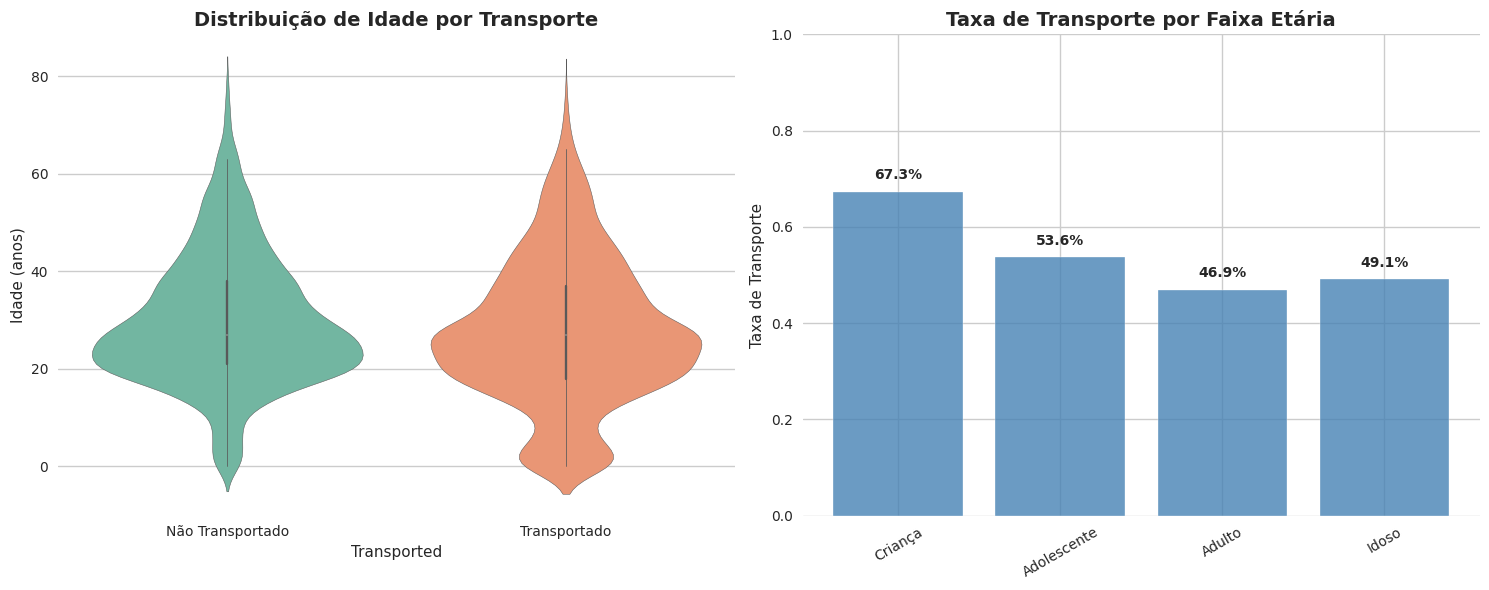

                  mean  count
Faixa_Etaria                 
Criança       0.672638    614
Adolescente   0.536372   1031
Adulto        0.469478   4980
Idoso         0.491145   1694


/tmp/ipykernel_1709/1578796926.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Faixa_Etaria')['Transported'].agg(['mean', 'count']))


In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(x='Transported', y='Age', data=df, palette='Set2', ax=ax1)
ax1.set_title('Distribuição de Idade por Transporte', fontsize=14, fontweight='bold')
ax1.set_xticklabels(['Não Transportado', 'Transportado'])
ax1.set_ylabel('Idade (anos)')

transporte_idade = df.groupby('Faixa_Etaria')['Transported'].mean()
ax2.bar(transporte_idade.index.astype(str), transporte_idade.values, color='steelblue', alpha=0.8)
ax2.set_title('Taxa de Transporte por Faixa Etária', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Transporte')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=30)
for i, v in enumerate(transporte_idade.values):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(df.groupby('Faixa_Etaria')['Transported'].agg(['mean', 'count']))

/tmp/ipykernel_1709/3908935446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transported', y='Gasto_Total', data=df, palette='coolwarm', ax=ax1)
/tmp/ipykernel_1709/3908935446.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Não Transportado', 'Transportado'])
/tmp/ipykernel_1709/3908935446.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transporte_gasto = df.groupby('Faixa_Gasto')['Transported'].mean()


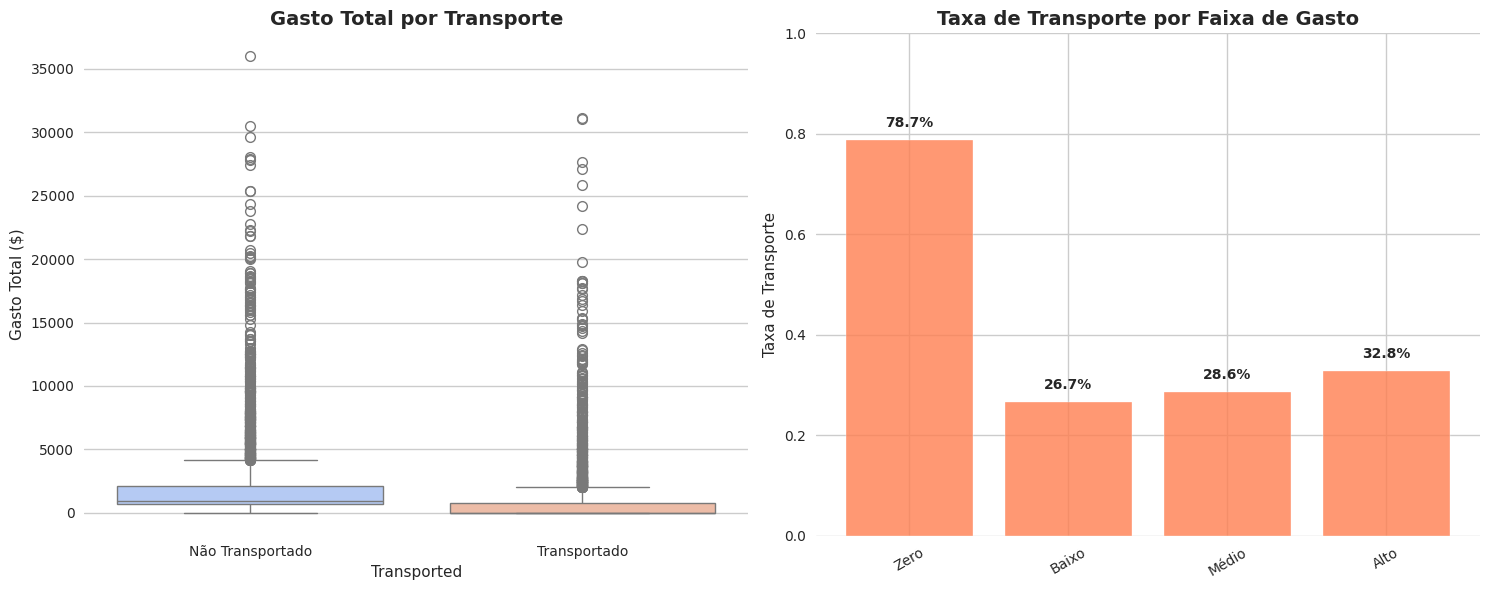

Correlação Gasto Total x Transportado: -0.196


In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Transported', y='Gasto_Total', data=df, palette='coolwarm', ax=ax1)
ax1.set_title('Gasto Total por Transporte', fontsize=14, fontweight='bold')
ax1.set_xticklabels(['Não Transportado', 'Transportado'])
ax1.set_ylabel('Gasto Total ($)')

df['Faixa_Gasto'] = pd.cut(df['Gasto_Total'], bins=[-1, 0, 500, 2000, 100000],
                            labels=['Zero', 'Baixo', 'Médio', 'Alto'])
transporte_gasto = df.groupby('Faixa_Gasto')['Transported'].mean()
ax2.bar(range(len(transporte_gasto)), transporte_gasto.values, color='coral', alpha=0.8)
ax2.set_title('Taxa de Transporte por Faixa de Gasto', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taxa de Transporte')
ax2.set_xticks(range(len(transporte_gasto)))
ax2.set_xticklabels(transporte_gasto.index, rotation=30)
ax2.set_ylim(0, 1)
for i, v in enumerate(transporte_gasto.values):
    ax2.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

correlacao_gasto = df['Gasto_Total'].corr(df['Transported'])
print(f"Correlação Gasto Total x Transportado: {correlacao_gasto:.3f}")

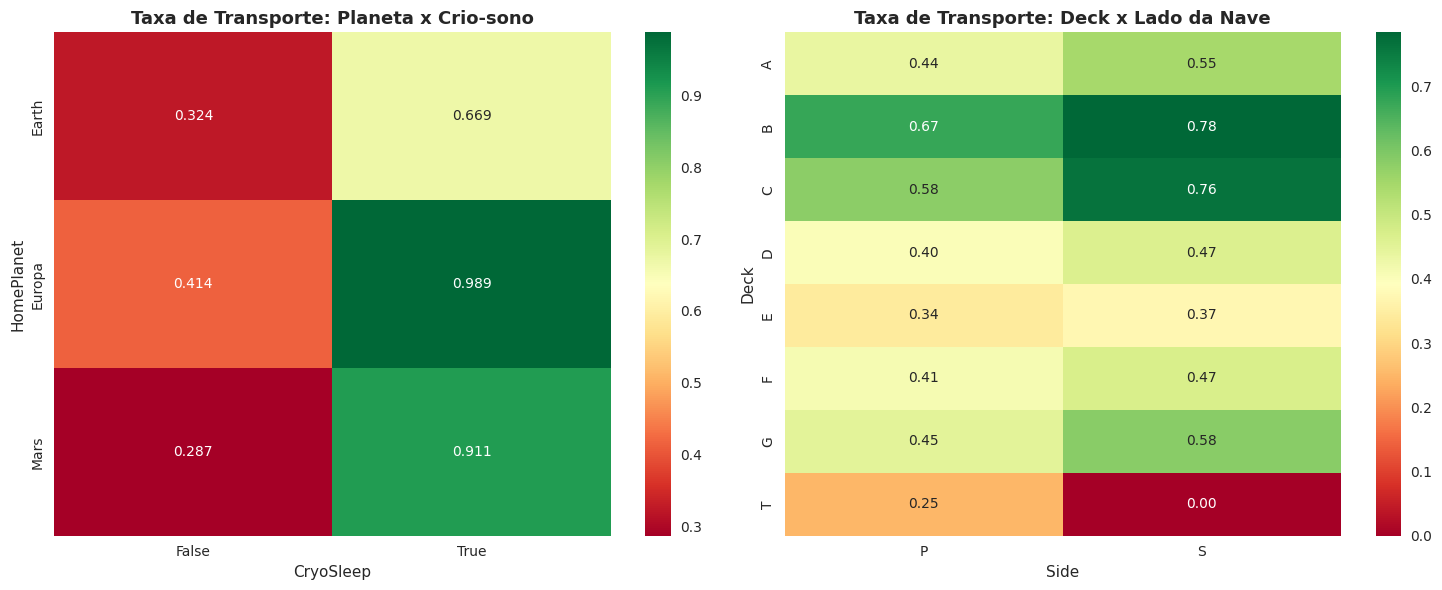

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pivot1 = df.pivot_table(values='Transported', index='HomePlanet', columns='CryoSleep', aggfunc='mean')
sns.heatmap(pivot1, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0])
axes[0].set_title('Taxa de Transporte: Planeta x Crio-sono', fontsize=13, fontweight='bold')

pivot2 = df.pivot_table(values='Transported', index='Deck', columns='Side', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Taxa de Transporte: Deck x Lado da Nave', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()